In [ ]:
######################## TASK1: DECODING A NOISE FREE MESSAGE
# The procedure is as below:
    # 1. Load the wav file
    # 2. Start from the given index (2625)
    # 3. For each sample, multiply by the attenuation level (100)
    # 4. Round the result to the nearest integer]
    # 5. convert to binary, considering two's complement if negative
    # 6. Extract the LSB
    # 7. Put all the LSBs together
    # 8. Read the result byte by byte, and find wich charcter each byte is equivalent to

from pydub import AudioSegment
import struct

def extract_message(wav_file_path, attenuation_level, step):
    ############## Load and normalized the WAV audio file via pydub
    audio = AudioSegment.from_wav(wav_file_path)

    # audio = effects.normalize(audio)

    ############### Extract the wav file characteristics (raw samples)
    sampwidth = audio.sample_width  # # of bytes per sample
    n_channels = audio.channels
    # DEBUG
    # print('no of channels: ', n_channels)
    raw_data = audio.raw_data    # the bytes
    total_samples = len(raw_data) // sampwidth
    
    ################ Unpack the audio samples
    # audio samples in wav files can be in one of these three formats:
        #   1. signed 8-bit integer (1 byte) => 'b'
        #   2. signed 16-bit integer (2 bytes) => 'h'
        #   3. signed 32-bit integer (3 bytes) => 'i'
    # Now we need a dictionary to map 'fmt' to the correct format code (for example if sampwidth = 2, then fmt = 'h')
    fmt_map = {1:'b', 2:'h', 4:'i'}
    fmt = fmt_map[sampwidth]
    # Now unpack the raw byte data into individual audio sample values
    # ''<' + fmt * total_samples' is the format string. For example, if fmt = 'h' and total_samples = 4, then the format string is '<hhhh'
    # we use '<', bc wav files are commonly little-endian
    samples = struct.unpack('<' + fmt * total_samples, raw_data)


    ########### Manual Normalize:
    max_input = max(abs(sample) for sample in samples)
    if max_input == 0:
        samples = list(samples)
    else:
        samples = [float((sample / max_input)) for sample in samples]


    # Calculate how many characters are hidden (length of the message)
    max_bytes = total_samples // (step * 8)
    # DEBUG     
    # print('Max bytes (calculated):', max_bytes)

    ########### Extract the hidden message
    bitlen = sampwidth * 8
    bits = []
    message = ''
    index = (step-1) * n_channels
    # In the line above, we wrote step-1, bc the python list is 0-indexed
    # In pydub, each frame is equivalent to the number of channels, multiplied by the samples (a sample is one amplitude measurement per channel).
    # So eventhough the number of channels is 1 in our case (as we have printed), is conceptually better to also do a multiplication by n_channels


    while index < total_samples and len(message) < max_bytes:
        # # DEBUG
        # print('samples[index] = ', samples[index])
        raw_val = samples[index]
        amplified = int(round(raw_val * attenuation_level))

        # two's-complement for negatives
        if amplified < 0:
            amplified = (1 << bitlen) + amplified

        # extract LSB
        bits.append(str(amplified & 1))

        # every 8 bits → one character
        if len(bits) == 8:
            byte_val = int(''.join(bits), 2)
            message += chr(byte_val)
            bits.clear()
        index += step * n_channels

    return message


message = extract_message("100-2625.wav", 100, 2625)
print("Hidden Message:", message)


Hidden Message: Signals & System


Signal is monophonic


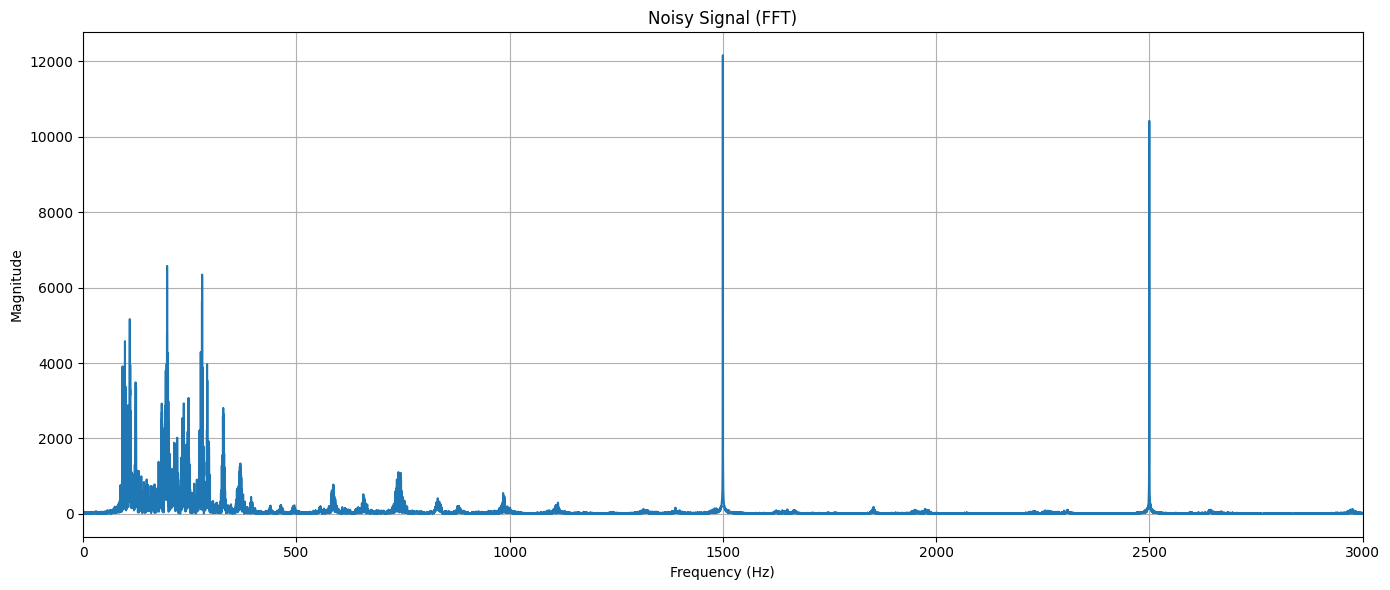

In [ ]:
######################## TASK2: DECODING A NOISY MESSAGE, PART 1: DETERMINING THE NOISE FREQUENCIES IN THE AUDIO BY PERFORMING FFT
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# FFT plotter function
def plot_fft(signal, sample_rate, title):
    N = len(signal)
    yf = np.abs(fft(signal))[:N // 2]
    xf = fftfreq(N, 1 / sample_rate)[:N // 2]
    plt.plot(xf, yf)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.xlim(0, 3000) # limits chosen to best showcase the noise frequencies

# Load the WAV audio file
audio = AudioSegment.from_wav("100-2625-noisy.wav")

# Get raw data as array of samples
samples = np.array(audio.get_array_of_samples())

# Extracting the properties of the audio:
sample_rate = audio.frame_rate
channels = audio.channels

# Handle stereo audio (2 channels)
if channels == 2:
    print('Signal is stereophonic')							   
    samples = samples.reshape((-1, 2))
else:
    print('Signal is monophonic')

samples = samples.astype(np.float64)
samples /= np.max(np.abs(samples))  # Normalize to -1.0 to 1.0

plt.figure(figsize=(14, 6))
plot_fft(samples, sample_rate, 'Noisy Signal (FFT)')
plt.tight_layout()
plt.show()


# RESULT: We have noise with frequencies 1500 and 2500 Hz

Signal is monophonic


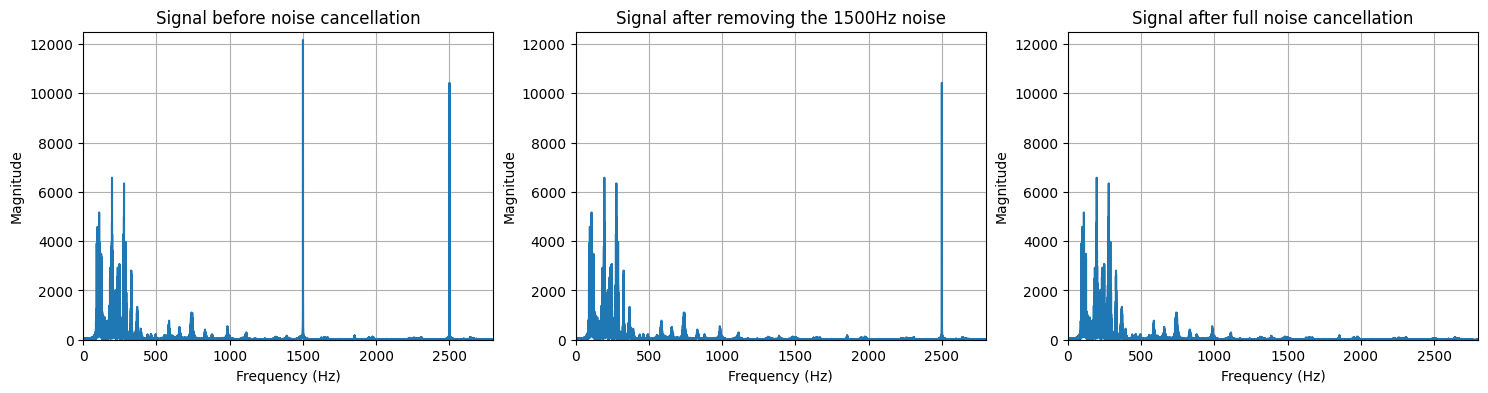

Hidden Message: Signals & System


In [32]:
######################## TASK2: DECODING A NOISY MESSAGE, PART 2: REMOVING THE NOISE AND DECODING THE MESSAGE
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import iirnotch, sosfilt
import struct

# FFT plotter function, used for contolling the noise cancellatio
def plot_fft(signal, sample_rate, title):
    N = len(signal)
    yf = np.abs(fft(signal))[:N // 2]
    xf = fftfreq(N, 1 / sample_rate)[:N // 2]
    plt.plot(xf, yf)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.xlim(0, 2800)
    plt.ylim(0, 12500)
    plt.tight_layout = True

# Since the only info we have in hand is the frequency spectrum of the noise and not necessarily the eact noise model, we preferably do not use adaptive filtering
# Now between IIR and FIR, IIR has lower computational cost, since sharp notches are achievable with low orders.
# IIR notch filter function, from "Noise cancelling.ipynb"
def iir_notch_filter(noisy_signal, sample_rate_in_Hz, notch_freq, quality_factor, num_stages):

    # Create multiple second-order sections
    sos = []
    for _ in range(num_stages):
        b, a = iirnotch(w0=notch_freq, Q=quality_factor, fs=sample_rate_in_Hz)
        sos.append([*b, *a])  # Flatten b and a into a single SOS row

    # Convert to np.array in SOS format
    sos = np.array(sos)

    # Apply cascaded biquad filtering
    filtered = sosfilt(sos, noisy_signal)

    # plot_filter_response(notch_freq, quality_factor, sample_rate_in_Hz)
    return filtered

# Message decoder function, same as TASK 1, only with the difference that this time, 
# we have the input is a set of samples (the output of the IIR filter), not the raw WAV file 
def extract_message_from_samples(samples, sampwidth, n_channels, attenuation_level, step):
    
    # Calculate how many characters are hidden (length of the message)
    total_samples = len(samples)
    max_bytes = total_samples // (step * 8)
    # DEBUG     
    # print('Max bytes (calculated):', max_bytes)

    ########### Extract the hidden message
    bitlen = sampwidth * 8
    bits = []
    message = ''
    index = (step-1) * n_channels
    # In the line above, we wrote step-1, bc the python list is 0-indexed
    # In pydub, each frame is equivalent to the number of channels, multiplied by the samples (a sample is one amplitude measurement per channel).
    # So eventhough the number of channels is 1 in our case (as we have printed), is conceptually better to also do a multiplication by n_channels


    while index < total_samples and len(message) < max_bytes:
        # # DEBUG
        # print('samples[index] = ', samples[index])
        raw_val = samples[index]
        amplified = int(round(raw_val * attenuation_level))

        # two's-complement for negatives
        if amplified < 0:
            amplified = (1 << bitlen) + amplified

        # extract LSB
        bits.append(str(amplified & 1))

        # every 8 bits → one character
        if len(bits) == 8:
            byte_val = int(''.join(bits), 2)
            message += chr(byte_val)
            bits.clear()
        index += step * n_channels

    return message


############################ LOADING THE WAV AUDIO FILE
audio = AudioSegment.from_wav("100-2625-noisy.wav")

# Get raw data as array of samples
samples = np.array(audio.get_array_of_samples())

# Extracting the properties of the audio:
sample_rate = audio.frame_rate
channels = audio.channels
sampwidth = audio.sample_width

# Handle stereo audio (2 channels)
if channels == 2:
    print('Signal is stereophonic')							   
    samples = samples.mean(axis=1)
else:
    print('Signal is monophonic')


raw_data = audio.raw_data
total_samples = len(raw_data) // sampwidth
# a dictionary to map 'fmt' to the correct format code (for example if sampwidth = 2, then fmt = 'h')
fmt_map = {1: 'b', 2: 'h', 4: 'i'}
fmt = fmt_map[sampwidth]

# Unpack samples
samples = struct.unpack('<' + fmt * total_samples, raw_data)
# Normalize samples
max_input = max(abs(sample) for sample in samples)
if max_input == 0:
    normalized_samples = np.array(samples, dtype=np.float32)
else:
    normalized_samples = np.array([sample / max_input for sample in samples], dtype=np.float32)




############################ NOISE CANCELLATION
quality_factor = 237
n_stages = 1

# DEBUG: CODE FOR FINDING THE BEST QUALITY FACTOR
# for quality_fac in range(200, 500, 1):
#     normalized_samples = iir_notch_filter(normalized_samples, sample_rate, 1500, quality_fac, n_stages)
#     normalized_samples = iir_notch_filter(normalized_samples, sample_rate, 2500, quality_fac, n_stages)
#     message = extract_message_from_samples(normalized_samples, sampwidth, channels, 100, 2625)
#     print(f"Quality factor = {quality_fac}:", message)


plt.figure(figsize=(18, 4))
# Plot FFT before noise cancellation
plt.subplot(1, 3, 1)
plot_fft(normalized_samples, sample_rate, 'Signal before noise cancellation')

# Apply IIR to cancel noise at 1500Hz
normalized_samples = iir_notch_filter(normalized_samples, sample_rate, 1500, quality_factor, n_stages)

# See to what extent the 1500Hz noise is removed
plt.subplot(1, 3, 2)
plot_fft(normalized_samples, sample_rate, 'Signal after removing the 1500Hz noise')


# Apply IIR to cancel noise at 2500Hz
normalized_samples = iir_notch_filter(normalized_samples, sample_rate, 2500, quality_factor, n_stages)

# See to what extent the 2500 noise is removed
plt.subplot(1, 3, 3)
plot_fft(normalized_samples, sample_rate, 'Signal after full noise cancellation')
plt.show()

############################ MESSAGE DECODING
message = extract_message_from_samples(normalized_samples, sampwidth, channels, 100, 2625)
print("Hidden Message:", message)